# Extended Figure 1 - Puro conventional cassettes
Tested in 293Ts, 20k cells/well at 96-well scale \ 
Sparsely labeled eGFP cells \ 
Infected at 6-well scale \
Reseed at 20k/well into antibiotic conditions \
Media change every other day \



Reps:
- 2026.06.06: 3 reps
- 2026.06.09: 1 rep


**Load in packages**

In [1]:
import rushd as rd
import matplotlib
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from textwrap import wrap
from statannotations.Annotator import Annotator
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.stats import poisson
from matplotlib.patches import Patch

In [2]:
alpha_tech_rep = 0.45
alpha_mean = 0.75
markersize = 7

**Statisics functions**

In [3]:
# Convert p-value to significance stars
def p_to_stars(p):
    if p < 0.0001:
        return '****'
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'


# Function for drawing brackets
def add_sig_bracket(ax, x1, x2, y, h, p):
    
    ax.plot(
        [x1, x1, x2, x2],
        [y, y+h, y+h, y],
        color='black',
        linewidth=1,
        clip_on=False
    )
    
    ax.text(
        (x1 + x2) / 2,
        y + h,
        p_to_stars(p),
        ha='center',
        va='bottom',
        fontsize=9
    )


## Load Data

In [ ]:
# Set paths to the experiment folder and where to find the data
base_path = rd.datadir/'data'/'attune'/'Mary'

Plates = {'2026.06.06_exp48': ['Plate1', 'Plate2', 'Plate3'],
            '2026.06.09_exp53': ['Plate1']
}

exp_path = []
yaml_path = []

for i in Plates:
    for j in Plates[i]:
        exp_path.append(base_path/i/j/'export_singlets')
        yaml_path.append(base_path/i/j/'export_singlets'/'well_metadata.yaml')

output_path = rd.rootdir/'output'/'ExtFig1_puro_cassettes'
cache_path = rd.rootdir/'output'/'ExtFig1_puro_cassettes'/'data.gzip'

plates_dict = pd.DataFrame({
    'data_path' : [exp for exp in exp_path],
    'yaml_path' : [yaml for yaml in yaml_path]
})

display(plates_dict)

,data_path,yaml_path
0,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
1,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
2,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
3,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...


In [5]:
#Load data
data = pd.DataFrame()
if cache_path.is_file(): data = pd.read_parquet(cache_path)
else:
    channel_list = ['mGL-H','mGL-A', 'iRFP670-A','iRFP670-H', 'FSC-A', 'SSC-A']
    data = rd.flow.load_groups_with_metadata(plates_dict,columns=channel_list) #Could add in columns=channel_list here to get specific columns

    # Remove NaN values
    data.dropna(inplace=True)

    # Save data in the cache path for easier loading next time
    data.to_parquet(rd.outfile(cache_path))


In [6]:
data['conds'] = data['reporter'] +'.'+ data['Puro'] 
display(data)

,reporter,Puro,Puro#,Date,well,population,FSC-A,SSC-A,mGL-A,mGL-H,iRFP670-A,iRFP670-H,conds
0,pCF0186,0x,0.0,2026.06.06.x,A1,Single Cells,373225,195050.0,81.0,67,76,68,pCF0186.0x
1,pCF0186,0x,0.0,2026.06.06.x,A1,Single Cells,640526,226449.0,131.0,78,37,55,pCF0186.0x
2,pCF0186,0x,0.0,2026.06.06.x,A1,Single Cells,837787,533513.0,199.0,126,94,90,pCF0186.0x
3,pCF0186,0x,0.0,2026.06.06.x,A1,Single Cells,447085,198291.0,46.0,74,158,95,pCF0186.0x
4,pCF0186,0x,0.0,2026.06.06.x,A1,Single Cells,150774,391435.0,106.0,86,32,94,pCF0186.0x
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7156535,pCF0187,40x,40.0,2026.06.09.x,H6,Single Cells,291704,388005.0,395.0,186,3734,3062,pCF0187.40x
7156536,pCF0187,40x,40.0,2026.06.09.x,H6,Single Cells,534676,523917.0,659.0,557,265,203,pCF0187.40x
7156537,pCF0187,40x,40.0,2026.06.09.x,H6,Single Cells,280905,255402.0,199.0,201,1035,672,pCF0187.40x
7156538,pCF0187,40x,40.0,2026.06.09.x,H6,Single Cells,354820,230615.0,144.0,76,189,105,pCF0187.40x


## EGFP Gating

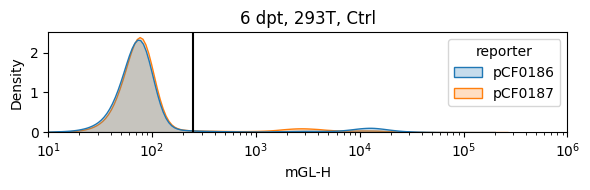

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 2))

# Threshold for iRFP670
mGL_H_thresh = 250

# Plot iRFP670-H
x = 'mGL-H'
hue = 'reporter'
hue_order = ['pCF0186', 'pCF0187']

data_now = data[(data['Puro'] == '0x') & (data['reporter'] != 'Untransfected') & (data[x] > 0) ]

sns.kdeplot(data=data_now,
        ax=ax, x=x, hue=hue,
        hue_order=hue_order,
        common_norm=False, log_scale=(True, False),
        fill=True)

# Plot threshold
ax.axvline(mGL_H_thresh, 0, 1, color='black')


# Title
plt.title('6 dpt, 293T, Ctrl')
# Adjust limits
mRuby2_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(mRuby2_lim)

# Misc plotting stuff
fig.tight_layout()  # Helps improve white spacing

**EGFP count dataframe**

In [9]:
# Categorize cells based on eGFP_thresh
data.loc[:, 'eGFP_cat'] = 'eGFP-'
data.loc[(data['mGL-H'] > mGL_H_thresh), 'eGFP_cat'] = 'eGFP+'

# Gate infected cells
df_use = data.copy()

# Get total counts and percent of GFP-H+ of the infected cells
group = [ 'reporter', 'conds', 'Date', 'Puro']
count_df_reps = df_use.groupby([*group, 'well', 'eGFP_cat'])[
    'mGL-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_eGFP_count_reps = count_df_reps.reset_index()

# Extract just the eGFP+
data_eGFP_percent_reps = percent_df_reps.loc[(percent_df_reps['eGFP_cat'] == 'eGFP+')]
data_eGFP_count_reps = data_eGFP_count_reps.loc[(data_eGFP_count_reps['eGFP_cat'] == 'eGFP+')]

In [10]:
# Convert to dataframe
data_eGFP_count_reps = count_df_reps.reset_index()

# Calculate total cells per well
total_cells = (
    data_eGFP_count_reps
    .groupby([*group, 'well'])['count']
    .sum()
    .reset_index(name='total_cells')
)

# Add total_cells column
data_eGFP_count_reps = data_eGFP_count_reps.merge(
    total_cells,
    on=[*group, 'well'],
    how='left'
)

In [13]:
Puro_conds = ['0x', '2.5x', '5x','10x','20x', '40x']

## Dot plots

**Extended Data Figure 1E: EGFP (%)**


EF1a
0 µg/mL: [9.26517036 7.72029167 8.17818123 8.83641331]
2.5 µg/mL: [97.17928919 97.03039019 93.917704   98.33165085]
n = 4 vs 4
t = -87.665, p = 1.484e-10

hPGK
0 µg/mL: [10.08814011  7.92468274  9.7764253   9.64670868]
2.5 µg/mL: [94.58630609 97.27673301 92.19512888 95.83920708]
n = 4 vs 4
t = -72.424, p = 4.663e-10

Significance: ns = p >= 0.05, * = p < 0.05, ** = p < 0.01, *** = p < 0.001, **** = p < 0.0001


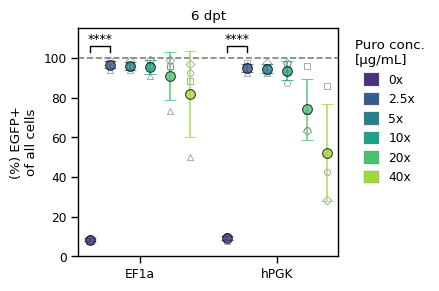

In [ ]:
# General plotting params
sns.set_context('paper')

x = 'reporter'
y = 'percent'

marker_list = ['o', 's', '^', 'D', 'P', 'X']

order = ['pCF0186', 'pCF0187']

antibiotic_map = {
    'pCF0186': 'Puro',
    'pCF0187': 'Puro'
}

label_map = {
    'pCF0186': 'EF1a',
    'pCF0187': 'hPGK'
}

df_curr = data_eGFP_percent_reps[
    data_eGFP_percent_reps['reporter'].isin(order)
].copy()

hue = 'Puro'
hue_order = Puro_conds


# ---------------------------------------------------------
# Calculate biological replicate means
# ---------------------------------------------------------

bio_means = (
    df_curr
    .groupby(
        ['reporter', 'conds', 'Puro', 'Date'],
        as_index=False
    )['percent']
    .mean()
)

summary = (
    bio_means
    .groupby(
        ['reporter', 'conds', 'Puro'],
        as_index=False
    )
    .agg(
        mean=('percent', 'mean'),
        sd=('percent', 'std'),
        sem=('percent', lambda x: x.std(ddof=1) / np.sqrt(len(x)))
    )
)

# ---------------------------------------------------------
# Statistics: 0 vs 2.5 Puro for each promoter
# ---------------------------------------------------------

from scipy.stats import ttest_ind

p_values = {}

for promoter in order:

    zero = bio_means.loc[
        (bio_means['reporter'] == promoter) &
        (bio_means['Puro'] == '0x'),
        'percent'
    ].dropna()

    forty = bio_means.loc[
        (bio_means['reporter'] == promoter) &
        (bio_means['Puro'] == '2.5x'),
        'percent'
    ].dropna()

    print(f"\n{label_map[promoter]}")
    print("0 µg/mL:", zero.values)
    print("2.5 µg/mL:", forty.values)
    print("n =", len(zero), "vs", len(forty))

    # Only run test if both groups have enough data
    if len(zero) >= 2 and len(forty) >= 2:

        t_stat, p_val = ttest_ind(
            zero,
            forty,
            equal_var=True,
            alternative='two-sided'
        )

        p_values[promoter] = p_val

        print(
            f"t = {t_stat:.3f}, "
            f"p = {p_val:.4g}"
        )

    else:
        p_values[promoter] = np.nan

        print(
            "Not enough biological replicates for t-test."
        )

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, ax = plt.subplots(1, 1, figsize=(4.5, 3))

colors = sns.color_palette(
    "viridis",
    len(hue_order)
)

# Horizontal offsets for each Puro concentration
offsets = np.linspace(
    -0.20,
    0.20,
    len(hue_order)
)

group_centers = [0, 0.55]


# ---------------------------------------------------------
# Plot biological replicate points
# ---------------------------------------------------------

for rep_idx, rep in enumerate(
    sorted(bio_means.Date.unique())
):

    rep_data = bio_means[
        bio_means.Date == rep
    ]

    for i, cond in enumerate(order):

        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data.reporter == cond) &
                (rep_data.Puro == puro)
            ]

            if row.empty:
                continue

            xloc = (
                group_centers[i] +
                offsets[j]
            )

            ax.scatter(
                xloc,
                row.percent.iloc[0],
                marker=marker_list[rep_idx],
                s=20,
                facecolors='white',
                edgecolors='black',
                linewidth=0.5,
                alpha=alpha_tech_rep,
                zorder=2
            )


# ---------------------------------------------------------
# Plot biological replicate mean ± SD
# ---------------------------------------------------------

for i, cond in enumerate(order):

    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.reporter == cond) &
            (summary.Puro == puro)
        ]

        if row.empty:
            continue

        xloc = (
            group_centers[i] +
            offsets[j]
        )

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=markersize,
            color=colors[j],
            alpha=alpha_mean,
            mec='black',
            mew=0.8,
            capsize=4,
            lw=1.3,
            zorder=5
        )


# ---------------------------------------------------------
# Add 0 vs 2.5 significance brackets
# ---------------------------------------------------------

# Find the positions of 0 and 2.5 in hue_order
zero_idx = list([0,2.5,5,10,20,40]).index(0)
two_idx = list([0,2.5,5,10,20,40]).index(2.5)

zero_offset = offsets[zero_idx]
two_offset = offsets[two_idx]


# EF1a
add_sig_bracket(
    ax,
    group_centers[0] + zero_offset,
    group_centers[0] + two_offset,
    y=103,
    h=3,
    p=p_values['pCF0186']
)


# hPGK
add_sig_bracket(
    ax,
    group_centers[1] + zero_offset,
    group_centers[1] + two_offset,
    y=103,
    h=3,
    p=p_values['pCF0187']
)


# ---------------------------------------------------------
# Formatting
# ---------------------------------------------------------

ax.yaxis.set_label_text(
    '(%) EGFP+\nof all cells'
)

ax.set_ylim((0, 115))

ax.axhline(
    100,
    color='grey',
    linestyle='--'
)

ax.set_xlabel('')

ax.set_xticks(group_centers)

ax.set_xticklabels(
    [label_map[l] for l in order]
)


# ---------------------------------------------------------
# Legend
# ---------------------------------------------------------

legend_handles = [
    Patch(
        facecolor=color,
        edgecolor='grey',
        label=str(puro),
        linewidth=0.2
    )
    for color, puro in zip(colors, hue_order)
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.\n[µg/mL]',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)


ax.set_title('6 dpt')

fig.tight_layout()

plottitle = 'Extended_Figure1E_EGFP_percent.svg'

plt.savefig(
    rd.outfile(output_path / plottitle),
    bbox_inches='tight'
)

**Extended Data Figure 1F: EGFP+ count**

EF1a: 0 vs 2.5 µg/mL, t = -2.149, p = 0.07525
hPGK: 0 vs 2.5 µg/mL, t = -1.678, p = 0.1443
EF1a: 0 µg/mL = 10919.38, 2.5 µg/mL = 34894.44, fold change = 3.20x
hPGK: 0 µg/mL = 10131.38, 2.5 µg/mL = 25082.50, fold change = 2.48x


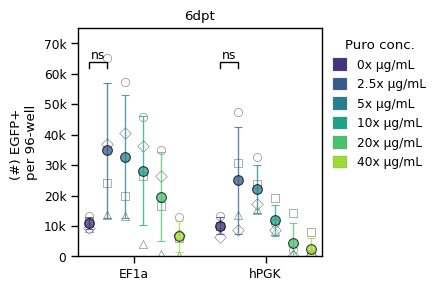

In [18]:
# General plotting params
x = 'reporter'
y = 'count'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['pCF0186', 'pCF0187']

df_curr = data_eGFP_count_reps[(data_eGFP_count_reps['reporter'].isin(order)) & (data_eGFP_count_reps['eGFP_cat'] == 'eGFP+')]

hue = 'Puro'
hue_order = Puro_conds


palette = sns.color_palette("viridis", len(hue_order))

# Horizontal offsets for each puro concentration
offsets = np.linspace(-0.12, 0.12, len(hue_order))
group_centers = [0, 0.35]

# Tiny offsets for technical replicates
rep_offsets = np.linspace(-0.02, 0.02, len(bio_means.Date.unique()))

# Calculate mean of biological replicate means

bio_means = (
    df_curr
    .groupby(['reporter','conds', 'Puro', 'Date'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['reporter','conds', 'Puro'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(4.5,3))

colors = dict(zip(hue_order, palette))

# Technical replicate dots (back layer)

unique_dates = sorted(bio_means.Date.unique())
rep_offsets = np.linspace(-0.02, 0.02, len(unique_dates))

markers = ['o', 's', '^', 'D', 'P', 'X']

for rep_idx, date in enumerate(unique_dates):

    rep_data = bio_means[bio_means.Date == date]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data.reporter == cond) &
                (rep_data.Puro == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y].iloc[0],
                marker=markers[rep_idx],
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_tech_rep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.reporter == cond) &
            (summary.Puro == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=markersize,
            color=colors[puro],
            alpha=alpha_mean,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

# ---------------------------------------------------------
# Statistics: 0 vs 2.5 Puro for each promoter
# ---------------------------------------------------------

from scipy.stats import ttest_ind

p_values = {}

for promoter in order:

    zero = bio_means.loc[
        (bio_means['reporter'] == promoter) &
        (bio_means['Puro'] == '0x'),
        y
    ].dropna()

    forty = bio_means.loc[
        (bio_means['reporter'] == promoter) &
        (bio_means['Puro'] == '2.5x'),
        y
    ].dropna()

    # Two-sided independent Student's t-test
    t_stat, p_val = ttest_ind(
        zero,
        forty,
        equal_var=True,
        alternative='two-sided'
    )

    p_values[promoter] = p_val

    print(
        f"{label_map[promoter]}: "
        f"0 vs 2.5 µg/mL, "
        f"t = {t_stat:.3f}, "
        f"p = {p_val:.4g}"
    )

# ---------------------------------------------------------
# Calculate fold change: 0 vs 2.5 µg/mL for each promoter
# ---------------------------------------------------------

for promoter in order:

    zero = bio_means.loc[
        (bio_means['reporter'] == promoter) &
        (bio_means['Puro'] == '0x'),
        'count'
    ].dropna()

    puro_2_5 = bio_means.loc[
        (bio_means['reporter'] == promoter) &
        (bio_means['Puro'] == '2.5x'),
        'count'
    ].dropna()

    # Mean across biological replicates
    zero_mean = zero.mean()
    puro_2_5_mean = puro_2_5.mean()

    # Fold change = 2.5 µg/mL / 0 µg/mL
    fold_change = puro_2_5_mean / zero_mean

    print(
        f"{label_map[promoter]}: "
        f"0 µg/mL = {zero_mean:.2f}, "
        f"2.5 µg/mL = {puro_2_5_mean:.2f}, "
        f"fold change = {fold_change:.2f}x"
    )
# ---------------------------------------------------------
# Add significance brackets
# ---------------------------------------------------------

zero_idx = list([0,2.5,5.,10,20,40]).index(0)
forty_idx = list([0,2.5,5.,10,20,40]).index(2.5)

zero_offset = offsets[zero_idx]
forty_offset = offsets[forty_idx]


# EF1a
add_sig_bracket(
    ax,
    group_centers[0] + zero_offset,
    group_centers[0] + forty_offset,
    y=62000,
    h=2000,
    p=p_values['pCF0186']
)


# hPGK
add_sig_bracket(
    ax,
    group_centers[1] + zero_offset,
    group_centers[1] + forty_offset,
    y=62000,
    h=2000,
    p=p_values['pCF0187']
)

# Formatting
ax.set_title('6dpt')
ax.yaxis.set_label_text('(#) EGFP+ \nper 96-well')
ax.xaxis.set_label_text('')
ax.set_ylim((0,75000))

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_xticks(group_centers)

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=0
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey', linewidth = 0.2,
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)

fig.tight_layout()

plottitle = 'Extended_Data_Figure1F_EGFP_number.svg'
plt.savefig(rd.outfile(output_path/plottitle))
